In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tabulate import tabulate

### Training a ConvNet for Simple Image Classification Tasks

An example of simple MNIST Digit Classification task with Convolution.

\_

The structure follows the same as previous DenseNet Notebook!

Best Notes on Convolution are still available in [Stanford Computer Vision Course](https://cs231n.github.io/convolutional-networks/)! Have a look.

In [3]:
(train_x, train_y), (test_x, test_y) = tf.keras.datasets.mnist.load_data()

print ('check shape of train data: ', train_x.shape, train_y.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
check shape of train data:  (60000, 28, 28) (60000,)


In [4]:
choose_image_index = 64

pixel_vals = train_x[choose_image_index]
print (pixel_vals.shape)

table = tabulate(pixel_vals, tablefmt="grid")

# Print the table
print(table)


print ('corresponding label: ', train_y[choose_image_index])

(28, 28)
+---+---+---+---+---+---+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+----+---+---+---+---+
| 0 | 0 | 0 | 0 | 0 | 0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |  0 | 0 | 0 | 0 | 0 |
+---+---+---+---+---+---+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+----+---+---+---+---+
| 0 | 0 | 0 | 0 | 0 | 0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |  0 | 0 | 0 | 0 | 0 |
+---+---+---+---+---+---+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+----+---+---+---+---+
| 0 | 0 | 0 | 0 | 0 | 0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |   0 |  0 | 0 | 0 | 0 | 0 |
+---+---+---+---+---+---+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

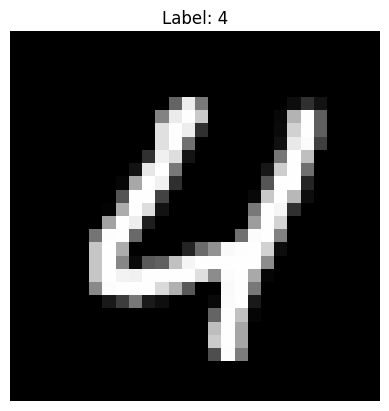

In [5]:
plt.imshow(train_x[choose_image_index], cmap='gray')
plt.title('Label: %s'%(train_y[choose_image_index]))
plt.axis('off')


### Pre-Processing Data




* In deep learning, data is stored in tensors. The term tensor applies to a scalar (0D tensor), vector (1D tensor), matrix (2D tensor), and a multi-dimensional tensor.

* Following lectures and previous notebook on DenseNet, here we are treating images as 'images' for ConvNet.


* Usually, for ConvNet the network is expecting the input to be in shape (N, H, W, C); where N is number of samples (usually in batch), H, W are height and width of the images and C is the number of channels; For MNIST we have only 1 channel.

_So No Need to flatten data anymore, just rearrange the shape_






In [6]:
train_x.shape

(60000, 28, 28)

In [7]:
# reshape and normalize
train_x_conv = train_x.reshape(-1, 28, 28, 1).astype('float32') / 255
print ('train_x_conv shape:', train_x_conv.shape)
test_x_conv = test_x.reshape(-1, 28, 28, 1).astype('float32') / 255

train_x_conv shape: (60000, 28, 28, 1)


### One Hot Encoding of Labels




* At this point, the labels are in digits format, 0 to 9.

* This sparse scalar representation of labels is not suitable for the neural network prediction layer that outputs probabilities per class.

  * say our network wants to predict 1, we want our output as `[0, 0.86, 0, 0, 0, 0, 0, 0.13, 0, 0.01]`

  * Then we can interpret this as class probabilities. 1 is most probable!  

* A more suitable format is called a one-hot vector, a 10-dim vector with all elements 0, except for the index of the digit class.

* For example, if the label is 2, the equivalent one-hot vector is `[0,0,1,0,0,0,0,0,0,0]`.

* The following lines convert each label into a one-hot vector:


In [8]:
###

from tensorflow.keras.utils import to_categorical

train_y_cat = to_categorical(train_y)
test_y_cat = to_categorical(test_y)

print ('check examples before and after: ', train_y[choose_image_index], '\n', train_y_cat[choose_image_index])

check examples before and after:  4 
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


### Build a Simple ConvNet

In [9]:
batch_size = 128


# compute the number of labels
num_labels = len(np.unique(train_y)) # just 10 different numbers from 0 to 9.


In [16]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense


model = tf.keras.models.Sequential([
    Input(shape=(28, 28, 1)),
    # layer1: Conv + Pool
    Conv2D(16, kernel_size=(3, 3), padding="same", activation='relu', ),
    MaxPooling2D(pool_size=(2, 2)),

    # layer2: Same
    Conv2D(32, kernel_size=(3, 3), padding="same", activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # layer 3: only Conv
    Conv2D(32, kernel_size=(3, 3), activation='relu'),

    # layer 4: flatten the previous layer outputs + final Classification
    Flatten(),
    Dense(16, activation='relu'),
    Dense(num_labels, activation='softmax')
])

In [17]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 5, 5, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │        12,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,034 (105.60 KB)

 Trainable params: 27,034 (105.60 KB)

 Non-trainable params: 0 (0.00 B)

### How Do We Justify the Number of Parameters?

Very different from DenseNet the number of params in Conv layer does not actually depend on the size of the image size but on the filters and number of input channels (for us it is only 1 channel);


* Weights: Each filter is $3\times 3$. Since the input (MNIST) is grayscale, it has 1 channel.

        3 (width)x3 (height)x1 (input channel)=9 weights per filter.

        With 16 filters, that is: 9x16=144 weights.

    Biases: 1 bias per filter.

        16 filters=16 biases.

    Total Params: 144+16= 160.

And so on....     

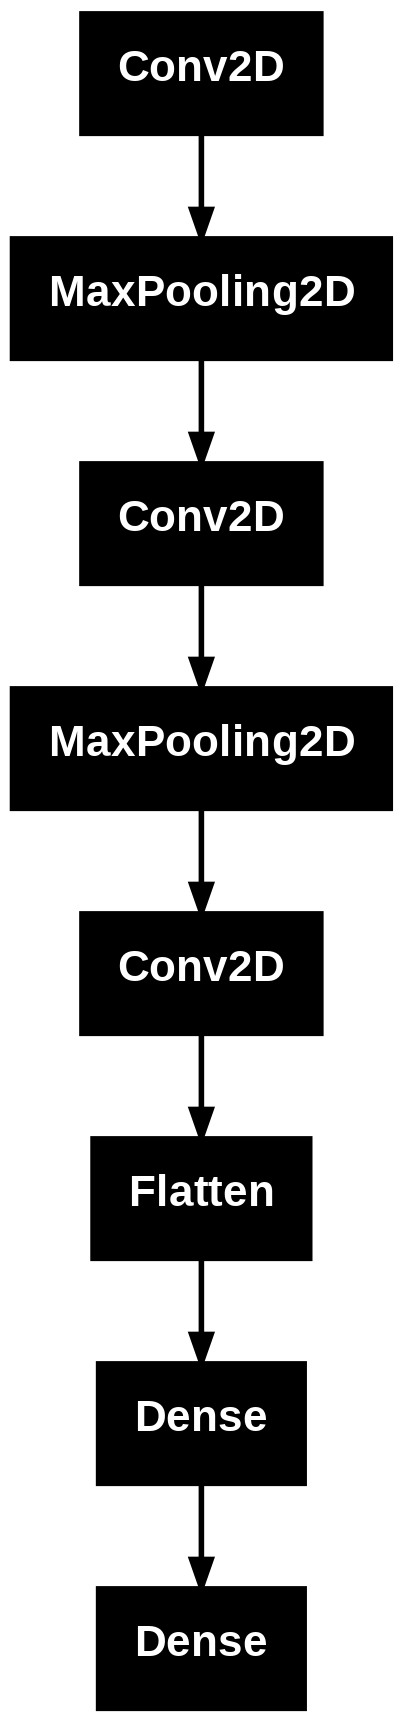

In [18]:
tf.keras.utils.plot_model(model)

In [19]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [20]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 5, 5, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │        12,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,034 (105.60 KB)

 Trainable params: 27,034 (105.60 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# fit the model

history = model.fit(train_x_conv, train_y_cat,
                    epochs=50, batch_size=batch_size)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.7566 - loss: 0.7448
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 65ms/step - accuracy: 0.9670 - loss: 0.1095
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 66ms/step - accuracy: 0.9762 - loss: 0.0763
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.9829 - loss: 0.0550
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 65ms/step - accuracy: 0.9861 - loss: 0.0441
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.9880 - loss: 0.0398
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - accuracy: 0.9890 - loss: 0.0340
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 65ms/step - accuracy: 0.9907 - loss: 0.0280
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.9925 - loss: 0.0260
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 67ms/step - accuracy: 0.9933 - loss: 0.0216
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 65ms/step - accuracy: 0.9937 - loss: 0.0203
Epoch 12/50
469/469 ━━━━━━━━━━

In [22]:
loss, acc = model.evaluate(test_x_conv, test_y_cat, batch_size=batch_size)
print("\nTest accuracy: %.1f%%" % (100.0 * acc))


79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9878 - loss: 0.0715

Test accuracy: 99.1%


### how does the loss behave?

Let's plot the loss as a function of training steps

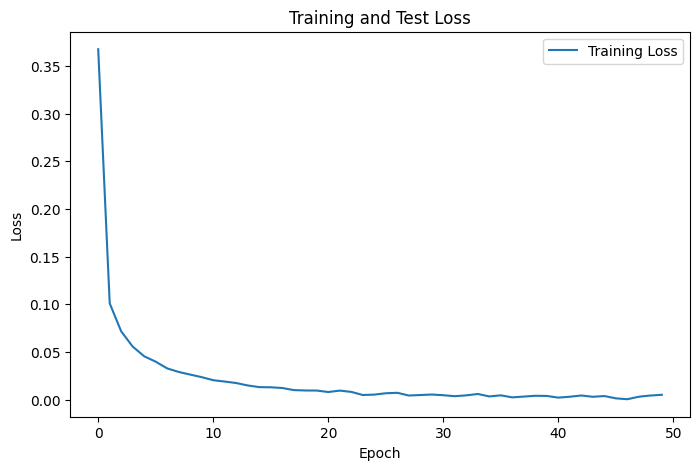

In [23]:

# Save the metrics.
metrics = history.history


# Save the loss values.
training_loss_list = metrics['loss']


# Plot the training and test loss.
x = np.arange(0, len(training_loss_list), 1)


fig = plt.figure(figsize=(8, 5))
plt.title('Training and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(x, training_loss_list, label='Training Loss')
plt.legend()
plt.show()



### Let's Check Some Predictions

In [24]:
predictions = model.predict(test_x_conv)

print ('what is predictions: ', type(predictions))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
what is predictions:  <class 'numpy.ndarray'>


In [ ]:
print ('shape of predictions: ', predictions.shape)

shape of predictions:  (10000, 10)


In [25]:
rand_indices = np.random.randint(0, 10000, 16)
print (rand_indices)

[2491 2362 6925  510 4728 5317 2208 7675 8865 5174 5769 2457 3503  670
 7164 4702]


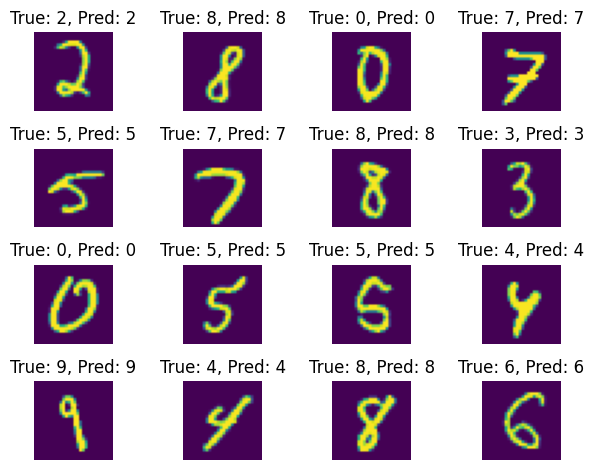

In [26]:
fig, axes = plt.subplots(4, 4)

# iterate over the axes and plot ims
for i, ax in enumerate(axes.flat):
    # load ims and plot it on the current axis
    image = test_x[rand_indices[i]]
    ax.set_title('True: %s, Pred: %s'%(test_y[rand_indices[i]], np.argmax(predictions[rand_indices[i]])))
    ax.imshow(image)
    ax.axis('off')

# adjust the space between subplts
plt.tight_layout()